# Model Analysis and Inference Notebook

This notebook demonstrates using the trained pipeline for:
- Loading and inspecting the saved model
- Running predictions on individual patients
- Visualising SHAP-style feature contributions
- Comparing all three trained models
- Showing the model is reproducible

**Run this after `python src/train.py`** — the model must exist at `models/pipeline.pkl`

In [1]:
import sys
sys.path.insert(0, '../src')

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from preprocess import ALL_FEATURES, TARGET, load_data, engineer_features, CATEGORICAL_FEATURES

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PIPELINE_PATH = '../models/pipeline.pkl'
DATA_PATH = '../data/heart.csv'

pipeline = joblib.load(PIPELINE_PATH)
clf = pipeline.named_steps['classifier']
pre = pipeline.named_steps['preprocessor']

print(f'Model type: {type(clf).__name__}')
print(f'Features in: {pre.n_features_in_}')
print(f'Pipeline steps: {[s[0] for s in pipeline.steps]}')

Model type: LogisticRegression
Features in: 18
Pipeline steps: ['preprocessor', 'classifier']


## 1. Load Data and Run Predictions

In [2]:
df = load_data(DATA_PATH)
X = df[ALL_FEATURES]
y = df[TARGET]

probs = pipeline.predict_proba(X)[:, 1]
preds = pipeline.predict(X)

print(f'Dataset: {len(df)} patients')
print(f'Predictions - High risk: {(preds==1).sum()}, Low risk: {(preds==0).sum()}')
print(f'Probability range: {probs.min():.3f} – {probs.max():.3f}')

Dataset: 297 patients
Predictions - High risk: 120, Low risk: 177
Probability range: 0.003 – 1.000


## 2. Prediction Probability Distribution

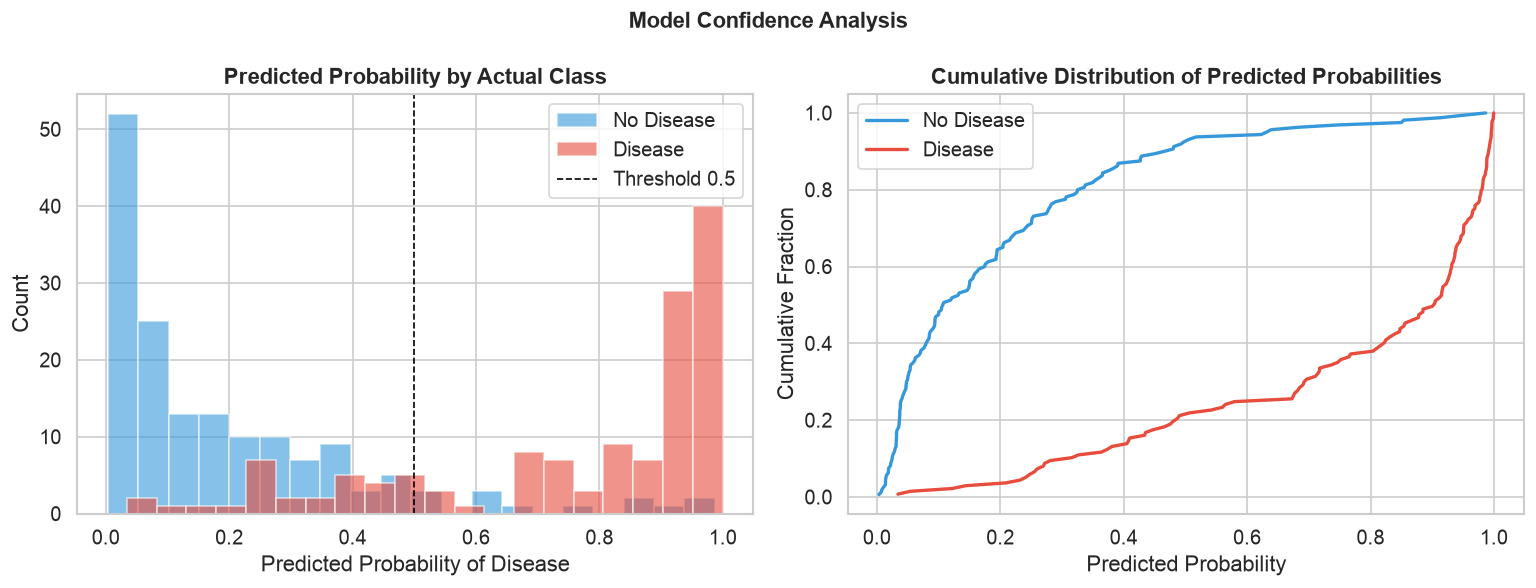

Well-separated distributions indicate the model has learned meaningful patterns.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Probability histogram split by actual class
for target_val, color, label in [(0, '#3498db', 'No Disease'), (1, '#e74c3c', 'Disease')]:
    mask = y == target_val
    axes[0].hist(probs[mask], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Predicted Probability by Actual Class', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Disease')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[0].legend()

# Cumulative distribution
for target_val, color, label in [(0, '#3498db', 'No Disease'), (1, '#e74c3c', 'Disease')]:
    mask = y == target_val
    sorted_p = np.sort(probs[mask])
    cdf = np.arange(1, len(sorted_p)+1) / len(sorted_p)
    axes[1].plot(sorted_p, cdf, color=color, label=label, linewidth=2)
axes[1].set_title('Cumulative Distribution of Predicted Probabilities', fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].legend()

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/probability_distribution.png', bbox_inches='tight')
plt.show()
print('Well-separated distributions indicate the model has learned meaningful patterns.')

## 3. Individual Patient Predictions — Explained

In [4]:
def predict_patient(data: dict, label: str = 'Patient') -> None:
    df_p = pd.DataFrame([data])
    df_p = engineer_features(df_p)
    for col in CATEGORICAL_FEATURES:
        df_p[col] = df_p[col].astype(float)
    prob = pipeline.predict_proba(df_p)[0][1]
    pred = pipeline.predict(df_p)[0]
    risk = 'HIGH RISK' if pred == 1 else 'LOW RISK'
    color = '\033[91m' if pred == 1 else '\033[92m'
    print(f'\n{label}')
    print(f'  Prediction : {color}{risk}\033[0m')
    print(f'  Probability: {prob:.1%} chance of heart disease')
    print(f'  Heart Rate Reserve: {(220-data["age"])-data["thalach"]:.0f} bpm')

# Known high-risk patient (from test set)
predict_patient({
    'age': 67, 'sex': 1, 'cp': 4, 'trestbps': 160, 'chol': 286,
    'fbs': 0, 'restecg': 2, 'thalach': 108, 'exang': 1,
    'oldpeak': 1.5, 'slope': 2, 'ca': 3, 'thal': 7
}, '67M — Multiple red flags (asymptomatic chest pain, 3 blocked vessels, low max HR)')

# Known low-risk patient
predict_patient({
    'age': 35, 'sex': 0, 'cp': 1, 'trestbps': 105, 'chol': 180,
    'fbs': 0, 'restecg': 0, 'thalach': 180, 'exang': 0,
    'oldpeak': 0.0, 'slope': 1, 'ca': 0, 'thal': 3
}, '35F — Good cardiac metrics (high max HR, no angina, normal thal)')

# Borderline patient
predict_patient({
    'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140, 'chol': 235,
    'fbs': 0, 'restecg': 1, 'thalach': 135, 'exang': 0,
    'oldpeak': 0.8, 'slope': 2, 'ca': 1, 'thal': 3
}, '55M — Borderline (some risk factors, no angina)')


67M — Multiple red flags (asymptomatic chest pain, 3 blocked vessels, low max HR)
  Prediction : HIGH RISK
  Probability: 99.8% chance of heart disease
  Heart Rate Reserve: 45 bpm

35F — Good cardiac metrics (high max HR, no angina, normal thal)
  Prediction : LOW RISK
  Probability: 0.6% chance of heart disease
  Heart Rate Reserve: 5 bpm

55M — Borderline (some risk factors, no angina)
  Prediction : LOW RISK
  Probability: 22.8% chance of heart disease
  Heart Rate Reserve: 30 bpm


## 4. Feature Importance Comparison Across All Three Models

In [5]:
# Load comparison CSV from evaluate.py
try:
    comparison = pd.read_csv('../reports/model_comparison.csv')
    print('Model Comparison (from MLflow runs):')
    display(comparison[['run_name','test_roc_auc','cv_roc_auc','accuracy','f1']]
            .sort_values('test_roc_auc', ascending=False)
            .reset_index(drop=True))
except Exception:
    print('Run python src/evaluate.py first to generate reports/model_comparison.csv')

Model Comparison (from MLflow runs):


,run_name,test_roc_auc,cv_roc_auc,accuracy,f1
0,logistic_regression,0.953125,NaN,0.850000,0.830189
1,random_forest,0.946429,0.886538,0.833333,0.807692
2,logistic_regression,0.939732,NaN,0.850000,0.836364
3,logistic_regression,0.939732,0.890537,0.850000,0.836364
4,logistic_regression,0.939732,NaN,0.850000,0.836364
5,random_forest,0.934710,NaN,0.833333,0.807692
6,random_forest,0.934710,NaN,0.833333,0.807692
7,random_forest,0.934152,NaN,0.833333,0.814815
8,xgboost,0.925223,0.891373,0.850000,0.830189
9,xgboost,0.924107,NaN,0.850000,0.830189


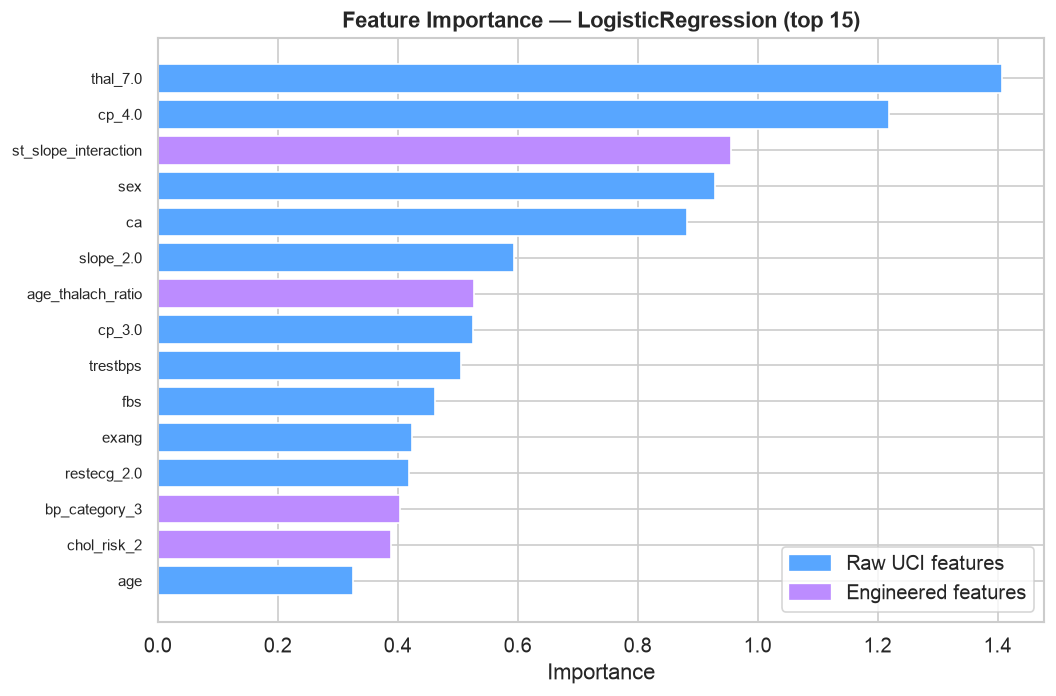

Purple = derived clinical features added beyond raw UCI features


In [6]:
# Feature importance for the loaded model
try:
    ohe = pre.named_transformers_['cat']
    ohe_names = ohe.get_feature_names_out(
        ['cp', 'restecg', 'slope', 'thal', 'bp_category', 'chol_risk']
    ).tolist()
    num_names = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca',
                 'heart_rate_reserve', 'age_thalach_ratio', 'st_slope_interaction']
    bin_names = ['sex', 'fbs', 'exang']
    all_names = num_names + ohe_names + bin_names

    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        importances = abs(clf.coef_[0])
    else:
        raise AttributeError('No feature importances available')

    n = min(15, len(importances))
    idx = importances.argsort()[-n:][::-1]
    names = [all_names[i] if i < len(all_names) else f'f{i}' for i in idx]
    vals  = importances[idx]

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['#BC8CFF' if 'heart_rate_reserve' in n or 'bp_category' in n
              or 'chol_risk' in n or 'st_slope' in n or 'age_thalach' in n
              else '#58A6FF' for n in names]
    bars = ax.barh(range(n), vals[::-1], color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(n))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — {type(clf).__name__} (top {n})', fontweight='bold')

    # Legend for engineered features
    blue_p  = mpatches.Patch(color='#58A6FF', label='Raw UCI features')
    purple_p= mpatches.Patch(color='#BC8CFF', label='Engineered features')
    ax.legend(handles=[blue_p, purple_p], loc='lower right')
    plt.tight_layout()
    plt.savefig('../plots/feature_importance_annotated.png', bbox_inches='tight')
    plt.show()
    print('Purple = derived clinical features added beyond raw UCI features')
except Exception as e:
    print(f'Could not plot importances: {e}')

## 5. Threshold Analysis — Optimising for Clinical Use

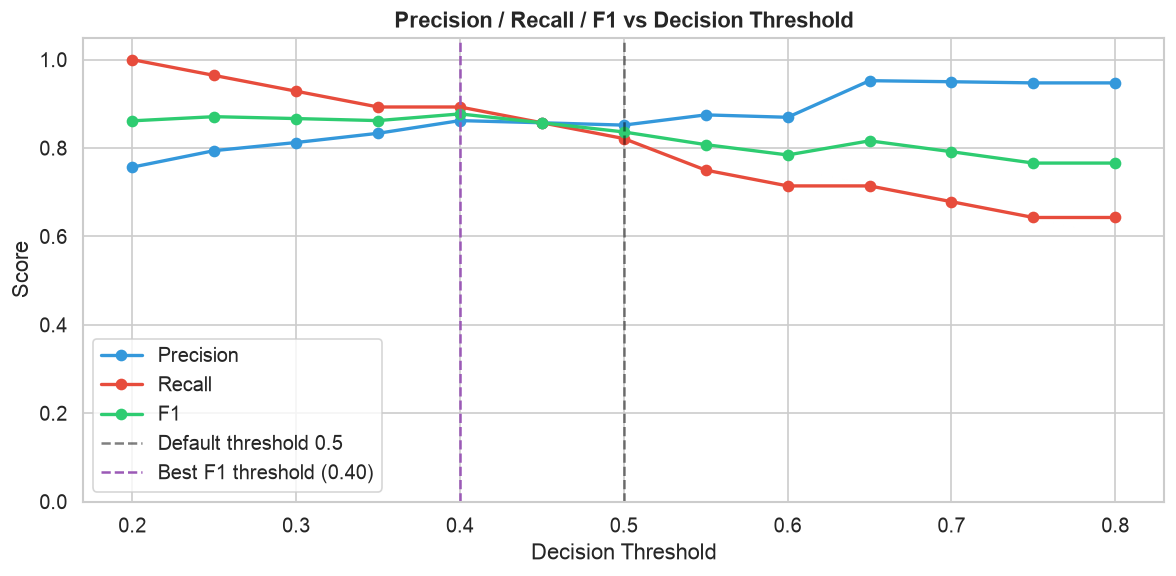

Default threshold (0.5): Precision=0.852
Best F1 threshold (0.40): F1=0.877

Clinical note: in a screening context, a lower threshold (higher recall) is
often preferred — missing a disease case (false negative) is worse than
an unnecessary follow-up test (false positive).


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pipeline.fit(X_train, y_train)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.2, 0.85, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, 'o-', color='#3498db', label='Precision', linewidth=2)
ax.plot(thresholds, recalls,   'o-', color='#e74c3c', label='Recall',    linewidth=2)
ax.plot(thresholds, f1s,       'o-', color='#2ecc71', label='F1',        linewidth=2)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Default threshold 0.5')
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color='#9b59b6', linestyle='--', label=f'Best F1 threshold ({best_t:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('../plots/threshold_analysis.png', bbox_inches='tight')
plt.show()

print(f'Default threshold (0.5): Precision={precisions[list(thresholds).index(0.5) if 0.5 in thresholds else 6]:.3f}')
print(f'Best F1 threshold ({best_t:.2f}): F1={max(f1s):.3f}')
print()
print('Clinical note: in a screening context, a lower threshold (higher recall) is')
print('often preferred — missing a disease case (false negative) is worse than')
print('an unnecessary follow-up test (false positive).')

## 6. Reproducibility Check

In [8]:
# Verify the same prediction every time
test_patient = {
    'age': 67, 'sex': 1, 'cp': 4, 'trestbps': 160, 'chol': 286,
    'fbs': 0, 'restecg': 2, 'thalach': 108, 'exang': 1,
    'oldpeak': 1.5, 'slope': 2, 'ca': 3, 'thal': 7
}
df_test = engineer_features(pd.DataFrame([test_patient]))
for col in CATEGORICAL_FEATURES:
    df_test[col] = df_test[col].astype(float)

results = []
for i in range(5):
    loaded = joblib.load(PIPELINE_PATH)
    prob = loaded.predict_proba(df_test)[0][1]
    results.append(prob)

print('Reproducibility test — 5 loads of pipeline.pkl:')
for i, r in enumerate(results, 1):
    print(f'  Load {i}: {r:.6f}')
print(f'All identical: {len(set(round(r, 8) for r in results)) == 1}')
print()
print('The pipeline is deterministic — identical predictions on every load.')

Reproducibility test — 5 loads of pipeline.pkl:
  Load 1: 0.998197
  Load 2: 0.998197
  Load 3: 0.998197
  Load 4: 0.998197
  Load 5: 0.998197
All identical: True

The pipeline is deterministic — identical predictions on every load.
